In [2]:
from pathlib import Path
import os
import sys

import numpy as np
import matplotlib.pyplot as plt
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

%load_ext autoreload
%autoreload 2
%matplotlib inline

cwd = Path.cwd().resolve()

# Locate helper_function by searching upward first, then common workspace locations.
def find_helper_folder(start: Path) -> Path:
    # 1) Directly in current/parent tree
    for p in [start, *start.parents]:
        candidate = p / "helper_function"
        if candidate.is_dir():
            return candidate

    raise FileNotFoundError("Could not find helper_function folder")


helper_path = find_helper_folder(cwd)
project_root = helper_path.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
if str(helper_path) not in sys.path:
    sys.path.insert(0, str(helper_path))

print("Project root:", project_root)
print("Current working directory:", cwd)
print("helper_function path:", helper_path)
print("helper_function exists:", helper_path.exists())

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Project root: /Users/JackX/projects/trap_sim_nullspace
Current working directory: /Users/JackX/projects/trap_sim_nullspace/lionix_gate/output_file/dc
helper_function path: /Users/JackX/projects/trap_sim_nullspace/helper_function
helper_function exists: True


In [3]:
charge = 1.602176634e-19  # Coulombs
mass = 40 * 1.66053906660e-27  # kg (mass of Ca+ ion)
Omega = 2 * np.pi * 50e6  # rad/s (RF drive frequency)
pseudo_factor = charge / (4 * mass * Omega**2)

In [113]:
import pickle
with open('mapping_data.pkl', 'rb') as f:
    data = pickle.load(f)
    mapping_dict = data['mapping_dict']
    mapping_list = data['mapping_list']

In [114]:
from post_process import read_post_processed
from field_analysis import analyze_dc_pot, print_field, fit_prep

electrode_num = 27
rf_electrode_index = [13]
gnd_electrode_index = [1, 2, 14, 20, 26, 27]
excitation_electrodes = set(range(1, electrode_num + 1)) - set(gnd_electrode_index) - set(rf_electrode_index)
excitation_electrodes = [3,4,5,6,7, 12,15, 16,17,18,19,21]
print("DC Excitation Electrodes:", excitation_electrodes)
excitation_electrodes = sorted(excitation_electrodes)
x, y, z, potentials = read_post_processed(filename="dc_transport_sim_out.h5", electrode_list=list(excitation_electrodes))

x_axis = x[:, 0, 0]
y_axis = y[0, :, 0]
z_axis = z[0, 0, :]

DC Excitation Electrodes: [3, 4, 5, 6, 7, 12, 15, 16, 17, 18, 19, 21]


In [115]:
dc_fields = {}

x0 = -250e-6
y0 = 0
z0 = 49.99e-6

omega = 2 * np.pi * 1e6
omega_r = 2 * np.pi * 4e6

dr = 1e-6

for i in excitation_electrodes:
    
    coeff, phi, grad, hessian = analyze_dc_pot(x, y, z, potentials[i], x0, y0, z0, dr)

    dc_fields[i] = (coeff, phi, grad, hessian)

In [116]:
A, _ = fit_prep(dc_fields, excitation_electrodes, target_phi = np.array([-0.25]), target_grad = np.array([0,0,0]), target_hessian = np.array([[1, 0, 0], [0, -1/2, 0], [0, 0, -1/2]])*mass*omega**2/(charge))

In [117]:
from post_process import read_from_artiq

old_voltage_sets = ['control_voltage/zone1/Vs_axial.csv', 
                    'control_voltage/zone1/Vs_xcomp.csv',
                    'control_voltage/zone1/Vs_ycomp.csv',
                    'control_voltage/zone1/Vs_zcomp.csv',
                    'control_voltage/zone1/Vs_tilt.csv',]

comp_applied = np.array([1, -12, 0, 40, 0.7])

V_sum = np.zeros((len(excitation_electrodes),))
for i, voltage_set in enumerate(old_voltage_sets):
    Vks = read_from_artiq(excitation_electrodes, mapping_dict, voltage_set)
    V_sum += comp_applied[i] * Vks

In [ ]:
b = A @ V_sum

phi, grad, upper_hessian = b[0], b[1:4], b[4:]
hessian = upper_vector_to_hessian(upper_hessian)
hessian = hessian + np.array([[0, 0, 0], [0, 1, 0], [0, 0, 1]]) * mass*(omega_r)**2/(charge)
print(f"Phi: {phi}")
print(f"Grad: {grad}")
print(f"Hessian: {hessian}")
print(f"Delta Pos (um): {-jnp.linalg.solve(hessian, grad)*1e6}")

eigvals, eigvecs = np.linalg.eigh(hessian)
eigvals = eigvals * charge / mass
print("Secular frequencies (MHz):", np.sqrt(eigvals)/(2*np.pi*1e6))
print("Eigenvectors (principal axes):", eigvecs)

Phi: 0.3347945503221029
Grad: [ 195.46078535  150.14986116 5512.75996826]
Hessian: [[ 2.69252944e+07 -2.32595896e+03  2.51640833e+06]
 [-2.32595896e+03  2.46037469e+08 -5.16854137e+07]
 [ 2.51640833e+06 -5.16854137e+07  2.50768393e+08]]
Delta Pos (um): [ -5.10502747  -5.45379095 -23.05631508]
Secular frequencies (MHz): [1.28191649 3.46658763 4.28245961]
Eigenvectors (principal axes): [[ 0.99992548 -0.01022714 -0.00666601]
 [-0.00279231 -0.72317666  0.69065746]
 [-0.01188416 -0.69058738 -0.72315132]]


In [96]:
from field_analysis import get_pot

excitation_electrodes = [3,4,5,6,7, 12,15, 16,17,18,19,21]
print("DC Excitation Electrodes:", excitation_electrodes)
excitation_electrodes = sorted(excitation_electrodes)
X, Y, Z, potentials = read_post_processed(filename="dc_transport_sim_out.h5", electrode_list=list(excitation_electrodes))


coeff = V_sum

x = -250e-6
y = 0
z = 49.99e-6
dr = 1e-6


for i in range(len(coeff)):

    el= excitation_electrodes[i]
    X_p, Y_p, Z_p, potential = get_pot(X, Y, Z, potentials[el], [-254e-6, -246e-6], [-4e-6, 4e-6], [46e-6,54e-6])

    if i == 0:
        total_potential = coeff[i] *  potential
    else:
        total_potential = total_potential + coeff[i] *  potential

DC Excitation Electrodes: [3, 4, 5, 6, 7, 12, 15, 16, 17, 18, 19, 21]


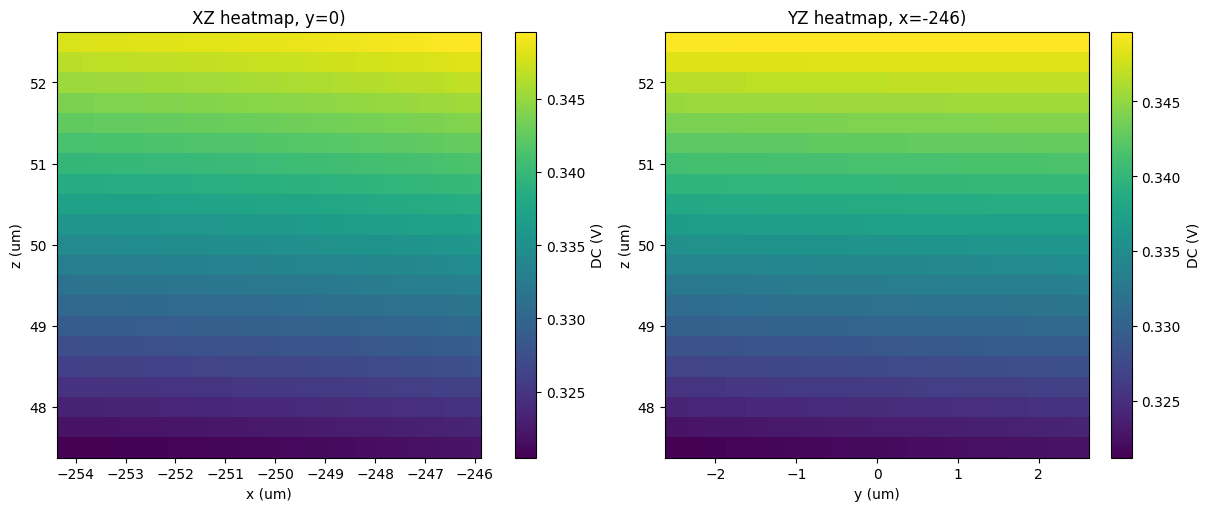

In [97]:
phi = total_potential

# Choose central slices (or closest to 0 if available).
x_axis = X_p[:, 0, 0]
y_axis = Y_p[0, :, 0]

x_idx = int(np.argmin(np.abs(x_axis - 0.0))) if np.any(np.isfinite(x_axis)) else X_p.shape[0] // 2
y_idx = int(np.argmin(np.abs(y_axis - 0.0))) if np.any(np.isfinite(y_axis)) else Y_p.shape[1] // 2

# xz slice at fixed y
X_xz = X_p[:, y_idx, :]
Z_xz = Z_p[:, y_idx, :]
P_xz = phi[:, y_idx, :]

# yz slice at fixed x
Y_yz = Y_p[x_idx, :, :]
Z_yz = Z_p[x_idx, :, :]
P_yz = phi[x_idx, :, :]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

hm1 = axes[0].pcolormesh(X_xz*1e6, Z_xz*1e6, P_xz, shading="auto", cmap="viridis")
axes[0].set_title(f"XZ heatmap, y={y_axis[y_idx]*1e6:.4g})")
axes[0].set_xlabel("x (um)")
axes[0].set_ylabel("z (um)")
fig.colorbar(hm1, ax=axes[0], label="DC (V)")

hm2 = axes[1].pcolormesh(Y_yz*1e6, Z_yz*1e6, P_yz, shading="auto", cmap="viridis")
axes[1].set_title(f"YZ heatmap, x={x_axis[x_idx]*1e6:.4g})")
axes[1].set_xlabel("y (um)")
axes[1].set_ylabel("z (um)")
fig.colorbar(hm2, ax=axes[1], label="DC (V)")

plt.show()

In [98]:
import h5py

with h5py.File("/Users/JackX/projects/trap_sim_nullspace/lionix_gate/output_file/rf/rf_pseudo_potential.h5", "r") as f:
    xpp = f["x"][:]
    ypp = f["y"][:]
    zpp = f["z"][:]
    phi_pp = f["rf_pp"][:]

In [99]:
x_pp_clipped, y_pp_clipped, z_pp_clipped, phi_pp_clipped = get_pot(xpp, ypp, zpp, phi_pp, [-4e-6, 4e-6], [-4e-6, 4e-6], [46e-6,54e-6])

In [100]:
# ...existing code...
from scipy.interpolate import RegularGridInterpolator

# Convert xpp/ypp/zpp to 1D axes if they are meshgrid arrays
xpp_axis = xpp[:, 0, 0] - 250e-6 if np.ndim(xpp) == 3 else xpp
ypp_axis = ypp[0, :, 0] if np.ndim(ypp) == 3 else ypp
zpp_axis = zpp[0, 0, :] if np.ndim(zpp) == 3 else zpp

# Ensure axes are increasing; reorder phi_pp accordingly
ix = np.argsort(xpp_axis)
iy = np.argsort(ypp_axis)
iz = np.argsort(zpp_axis)

xpp_axis = xpp_axis[ix]
ypp_axis = ypp_axis[iy]
zpp_axis = zpp_axis[iz]
phi_pp_sorted = phi_pp[np.ix_(ix, iy, iz)]

# Build interpolator
rgi = RegularGridInterpolator(
    (xpp_axis, ypp_axis, zpp_axis),
    phi_pp_sorted,
    method="linear",
    bounds_error=False,
    fill_value=np.nan,
)

# Query at DC grid points (X_p, Y_p, Z_p)
query_points = np.column_stack([X_p.ravel(), Y_p.ravel(), Z_p.ravel()])
phi_pp_on_dc_grid = rgi(query_points).reshape(X_p.shape)

print("Interpolated RF pseudo-potential shape:", phi_pp_on_dc_grid.shape)
print("NaN count (outside RF grid bounds):", np.isnan(phi_pp_on_dc_grid).sum())

Interpolated RF pseudo-potential shape: (34, 21, 21)
NaN count (outside RF grid bounds): 0


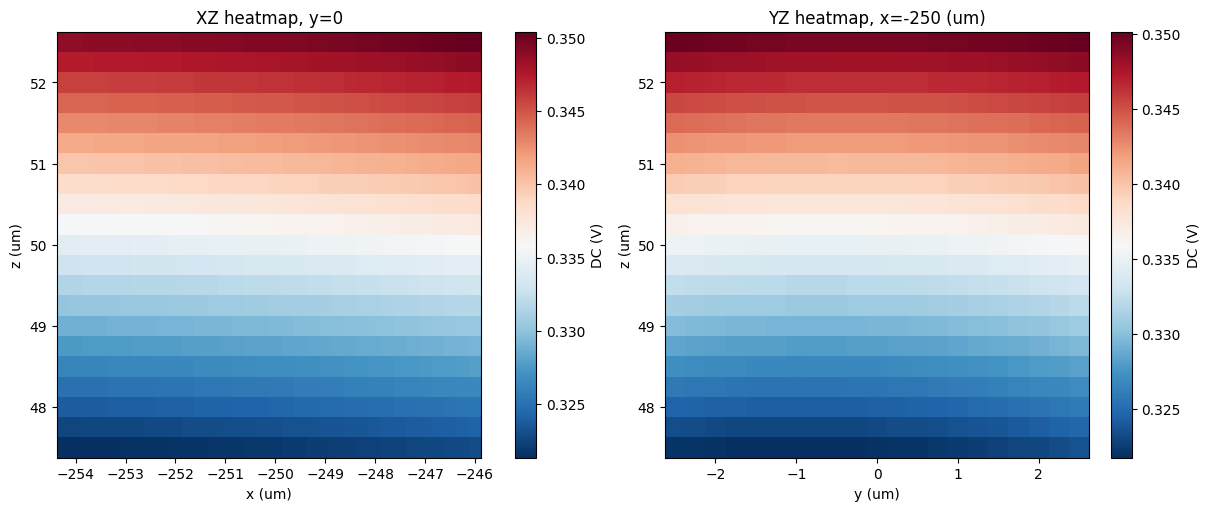

In [101]:
phi = total_potential + phi_pp_on_dc_grid

# Choose central slices (or closest to 0 if available).
x_axis = X_p[:, 0, 0]
y_axis = Y_p[0, :, 0]

x_idx = int(np.argmin(np.abs(x_axis + 250e-6))) if np.any(np.isfinite(x_axis)) else X_p.shape[0] // 2
y_idx = int(np.argmin(np.abs(y_axis - 0.0))) if np.any(np.isfinite(y_axis)) else Y_p.shape[1] // 2

# xz slice at fixed y
X_xz = X_p[:, y_idx, :]
Z_xz = Z_p[:, y_idx, :]
P_xz = phi[:, y_idx, :]

# yz slice at fixed x
Y_yz = Y_p[x_idx, :, :]
Z_yz = Z_p[x_idx, :, :]
P_yz = phi[x_idx, :, :]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

hm1 = axes[0].pcolormesh(X_xz*1e6, Z_xz*1e6, P_xz, shading="auto", cmap="RdBu_r")
axes[0].set_title(f"XZ heatmap, y={y_axis[y_idx]*1e6:.4g}")
axes[0].set_xlabel("x (um)")
axes[0].set_ylabel("z (um)")
fig.colorbar(hm1, ax=axes[0], label="DC (V)")

hm2 = axes[1].pcolormesh(Y_yz*1e6, Z_yz*1e6, P_yz, shading="auto", cmap="RdBu_r")
axes[1].set_title(f"YZ heatmap, x={x_axis[x_idx]*1e6:.4g} (um)")
axes[1].set_xlabel("y (um)")
axes[1].set_ylabel("z (um)")
fig.colorbar(hm2, ax=axes[1], label="DC (V)")

#fig.savefig("control_voltage/plot/total_potential.pdf", bbox_inches='tight')
plt.show()

In [129]:
new_voltage_sets = ['control_voltage/Vs_axial.csv', 
                    'control_voltage/Vs_xcomp.csv',
                    'control_voltage/Vs_ycomp.csv',
                    'control_voltage/Vs_zcomp.csv',
                    'control_voltage/Vs_tilt.csv',]

comp_applied = np.array([1, -12, -0.214, -18.8, 1])

V_sum = np.zeros((len(excitation_electrodes),))
for i, voltage_set in enumerate(new_voltage_sets):
    Vks = read_from_artiq(excitation_electrodes, mapping_dict, voltage_set)
    V_sum += comp_applied[i] * Vks

b = A @ V_sum

phi, grad, upper_hessian = b[0], b[1:4], b[4:]
hessian = upper_vector_to_hessian(upper_hessian)
hessian = hessian + np.array([[0, 0, 0], [0, 1, 0], [0, 0, 1]]) * mass*(omega_r)**2/(charge)
print(f"Phi: {phi}")
print(f"Grad: {grad}")
print(f"Hessian: {hessian}")
print(f"Delta Pos (um): {-jnp.linalg.solve(hessian, grad)*1e6}")

eigvals, eigvecs = np.linalg.eigh(hessian)
eigvals = eigvals * charge / mass
print("Secular frequencies (MHz):", np.sqrt(eigvals)/(2*np.pi*1e6))
print("Eigenvectors (principal axes):", eigvecs)

Phi: 0.05726673139815428
Grad: [ 196.40145032   56.03977608 4923.06674189]
Hessian: [[3.48330680e+07 1.13243199e+03 2.60666476e+06]
 [1.13243199e+03 2.54813874e+08 6.54206692e+07]
 [2.60666476e+06 6.54206692e+07 2.34084214e+08]]
Delta Pos (um): [ -3.95156352   5.5678235  -22.54324203]
Secular frequencies (MHz): [1.45807897 3.30006951 4.35701124]
Eigenvectors (principal axes): [[ 0.99988574  0.01381344 -0.00614021]
 [ 0.00430366 -0.64950218 -0.76034755]
 [-0.0144911   0.76023425 -0.64948741]]


In [131]:
new_voltage_sets = ['control_voltage/Vs_axial.csv', 
                    'control_voltage/Vs_xcomp.csv',
                    'control_voltage/Vs_ycomp.csv',
                    'control_voltage/Vs_zcomp.csv',
                    'control_voltage/Vs_tilt.csv',]

comp_applied = np.array([1, -12, -0.214, -18.8, 1])

V_sum = np.zeros((len(excitation_electrodes),))
for i, voltage_set in enumerate(new_voltage_sets):
    Vks = read_from_artiq(excitation_electrodes, mapping_dict, voltage_set)
    V_sum += comp_applied[i] * Vks

b = A @ V_sum

phi, grad, upper_hessian = b[0], b[1:4], b[4:]
hessian = upper_vector_to_hessian(upper_hessian)
print(f"Phi: {phi}")
print(f"Grad: {grad}")
print(f"Hessian: {hessian}")

Phi: 0.05726673139815428
Grad: [ 196.40145032   56.03977608 4923.06674189]
Hessian: [[ 3.48330680e+07  1.13243199e+03  2.60666476e+06]
 [ 1.13243199e+03 -7.05170362e+06  6.54206692e+07]
 [ 2.60666476e+06  6.54206692e+07 -2.77813644e+07]]


In [132]:
print(V_sum)

[ 5.94389375  0.80349283 -3.51131539  1.3864535   6.05088843  0.11375266
 -0.71119851  6.08156037  1.3664404  -2.19369004  1.94582369  6.19005885]


In [135]:
Vs =  np.array([5.05465316,  1.18319789, -3.66712429,  1.97181296,  3.11130186,
        2.4335795 ,  1.71976225,  1.23431322,  0.89394083,  0.1150738 ,
       -0.71348594,  5.19298412,  1.7513634 , -2.34756039,  2.53367648,
        3.24997328,  2.47817067,  1.74495684,  1.24520817,  0.90602401])